In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Tensors

Similar to numpy arrays and matrices
- encode inputs and outputs of model
- encode model parameters

Key points
- can create directly or convert from numpy array - if converting either way between these will share memory location and so modifying one will modify the other
- can perform standard matrix arithmetic on tensors
- if moving to an accelerator must check one is available then manually move it other

In [3]:
import torch
import numpy as np

In [4]:
#can be created directly from data or converted from numpy array
data = [[1, 2], [3, 4]]

x_data = torch.tensor(data)
print(x_data)

x_data = torch.from_numpy(np.array(data))
print(x_data)

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]])


In [5]:
# tensors keep propoerties of orig data unless overriden
x_rand = torch.rand_like(x_data, dtype = torch.float32)
print(x_rand)

tensor([[0.9920, 0.9266],
        [0.9665, 0.0020]])


In [6]:
#can use `shape` to determine shape of resulting tensor
shape = (2, 3, )
rand_tensor = torch.rand(shape)
print(rand_tensor)

tensor([[0.9628, 0.1547, 0.0810],
        [0.8063, 0.1331, 0.0391]])


In [7]:
#tensor has 3 main attributes, shape, dtype and device on which they are stored
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [8]:
#need to explicity move a tensor to an accelerator if they are available
if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())
tensor.device

device(type='cuda', index=0)

In [9]:
#tensor handling is the same as numpy arrays
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [10]:
#torch.cat can be used to join tensors along a given dimension
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [11]:
#can also perform arithmetic on tensors
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)
print('y1')
print(y1)
print('y2')
print(y2)
print('y3')
print(y3)


# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)
print('z1')
print(z1)
print('z2')
print(z2)
print('z3')
print(z3)


y1
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
y2
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
y3
tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
z1
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
z2
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
z3
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [12]:
#this allows you to convert a single element tensor to. a python integer
agg = tensor.sum()
agg_item = agg.item()
print(agg, type(agg))
print(agg_item, type(agg_item))

tensor(12.) <class 'torch.Tensor'>
12.0 <class 'float'>


In [13]:
#all in place operations denoted by _ suffix
tensor.add_(5)
print(tensor)
tensor.t_()
print(tensor)

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])
tensor([[6., 6., 6., 6.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [6., 6., 6., 6.]])


In [15]:
# Bridging with numpy
#CPU tensors can share location with numpy array - changing one will change the other
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [16]:
#changing the tensor then changes the array
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [17]:
#this works both ways
n = np.ones(5)
t = torch.from_numpy(n)

np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


# Datasets and Data Loaders

Idea is to decouple dataset code from model code for better readability and modularity
- dataset is a class that stores datasets so they have common features
- DatasetLoader is an iterable that can be wrapped around a dataset

In [18]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

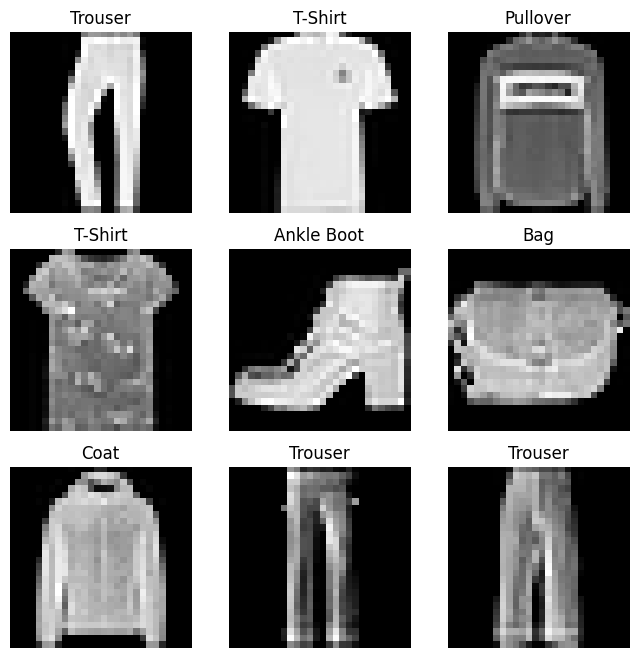

In [21]:
#datasets can be accessed like arrays by index

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Custom dataset class must have these 3 functions
- needs an __init__, __len__, __getitem__
- the __len__ function simply returns the number of samples in the dataset
- rest are broken down below

In [1]:
import os
import pandas as pd
from torchvision.io import decode_image

#annotations in annotations_file.csv
#image is in img_dir
class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

KeyboardInterrupt: 

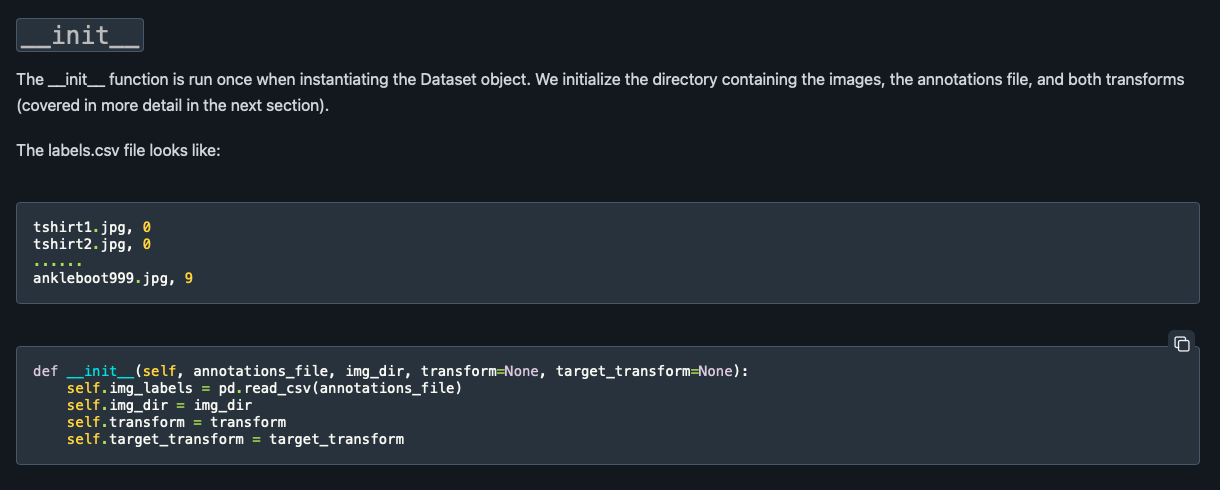

__getitem__ retrieves an item from the dataset via the passed index

In this example
- retrieves img by index from disk
- converts it to a tensor via decode_image
- transforms it if applicable
- fetches label by index too
- returns image as (transformed) tensor and label

In [ ]:
def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image = decode_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
        image = self.transform(image)
    if self.target_transform:
        label = self.target_transform(label)
    return image, label

In [22]:
#dataset retrieves the samples one element at a time, dataloader is an iterable that handles things like batch training and shuffling for us
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

#in this case returning 64 train samples (images) and their labels

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


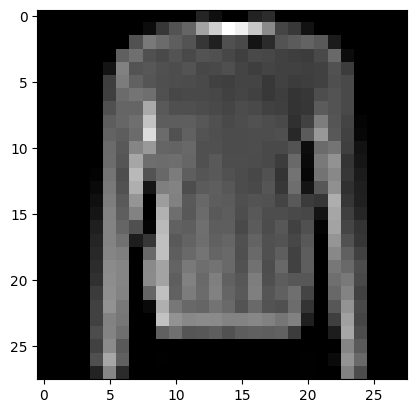

Label: 2


In [23]:
#As we have specified shuffle=True, when iterating through the entire dataset still only get each sample once but in a random order

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# Transforms

Often samples and labels are not in a format suitable for machine learning
- here images must be converted to tensors, labels must be 1 hot encode (rather than 1-10)
- can specify feature transforms in dataset via (transform) and label transforms via (target_transform)
- both accept callables containing transform logic, and torch offers some common ones out of the box

In [24]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

#ToTensor convert PIL image to normalised tensor
#target_transfrom uses lambda to one hot encode 1-10 labels
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

In [ ]:
#here torch.zeros creates empty tensor of 10 zeros (number of label types) and scatter assigns a 1 to the index provided by y (the sample type specified by original number)
target_transform = Lambda(lambda y: torch.zeros(
    10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

Lambda()

# Building Neural Network

nn consists of layers/modules - each performing an operation on the data
- every pytorch module subclasses the nn.Module
- neural network is module of modules - this allows you to create the complex architecture

In [27]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [28]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
#initialise a neural network module
# creates a stack of linear and then reLu activtion functions
# all operations on input data in nn specified in the forward method

In [29]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [30]:
#then create an instance of the model
# like tensors move this to the accelerator manually
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
#to use models you pass an instance the input data, never called .forward() manually
#output is 2d tensor where dim=0 are each output of (in this case 10) predicted values, and dim=1 corresponding to the predicted value for each input
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([4], device='cuda:0')


In [33]:
# This creates a mini dataset of 3 28x28 images
input_image = torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])


In [34]:
#flatten converts each 28x28 array into one 784 pixel array
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


In [35]:
#linear layers uses stored weights and biases apply a linear transformation to input data
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [36]:
#ReLU is one of many activation functions that allow neural networks to learn non-linear behaviour
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-0.1709, -0.2745, -0.2237, -0.5768, -0.1103,  0.0026,  0.2283,  0.0491,
          0.6997, -0.2407,  0.5517,  0.3072,  0.0444,  0.2457, -0.1632, -0.1138,
          0.2824,  0.1648, -0.4520, -0.6778],
        [-0.1055, -0.4294, -0.5582, -0.4397,  0.1289,  0.2581, -0.2848,  0.0814,
          0.0723, -0.2153,  0.7205,  0.6228,  0.1323,  0.4207, -0.4957, -0.2658,
          0.0426,  0.0106, -0.5275, -0.4359],
        [ 0.1793, -0.4448, -0.3226, -0.7222, -0.1031, -0.0246,  0.0521,  0.1995,
          0.1257, -0.0777,  0.6344,  0.4572,  0.0438,  0.3797, -0.7190,  0.0008,
          0.6875,  0.0140, -0.2403, -0.5121]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0026, 0.2283, 0.0491, 0.6997,
         0.0000, 0.5517, 0.3072, 0.0444, 0.2457, 0.0000, 0.0000, 0.2824, 0.1648,
         0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.1289, 0.2581, 0.0000, 0.0814, 0.0723,
         0.0000, 0.7205, 0.6228, 0.1323, 0.4207, 0.00

In [37]:
#nn.Sequential is a container that stores modules in order. Passing input data through the container then runs the layers in order
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

In [39]:
#logits (raw values in range [-inf, inf]) is the output of this model
#Softmax scales these values to [0,1] reprensenting the probability each image belongs to each of the 10 classes (object types), dim sepcifies the axes that must sum to 1 (as probabilities)

softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
pred_probab

tensor([[0.0867, 0.0994, 0.0705, 0.1228, 0.1036, 0.0914, 0.0608, 0.1094, 0.1300,
         0.1253],
        [0.0887, 0.1057, 0.0815, 0.1311, 0.1114, 0.0890, 0.0720, 0.1003, 0.1130,
         0.1074],
        [0.0824, 0.1144, 0.0741, 0.1297, 0.0908, 0.0944, 0.0652, 0.1130, 0.1225,
         0.1136]], grad_fn=<SoftmaxBackward0>)

In [ ]:
#each layer has stored weights and biases learnt during training - as have subclassed nn.Module can access these stored values
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0052, -0.0098, -0.0099,  ..., -0.0177, -0.0319, -0.0046],
        [-0.0108, -0.0215,  0.0216,  ...,  0.0300,  0.0240,  0.0282]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([ 0.0356, -0.0154], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0029, -0.0089, -0.0217,  ...,  0.0131, -0.0356,  0.0415],
        [ 0.0113,  0.0420,  0.0027,  ..., -0.0313,  0.0427, -0.0014]],
       device='cuda:0', grad_fn=<Sl

# Auto-grad for automatic differentiation

Almost all neural networks uses backpropogation to adjust model weights (parameters)
- adjusted according to the gradient of the loss function with respect to given parameter value

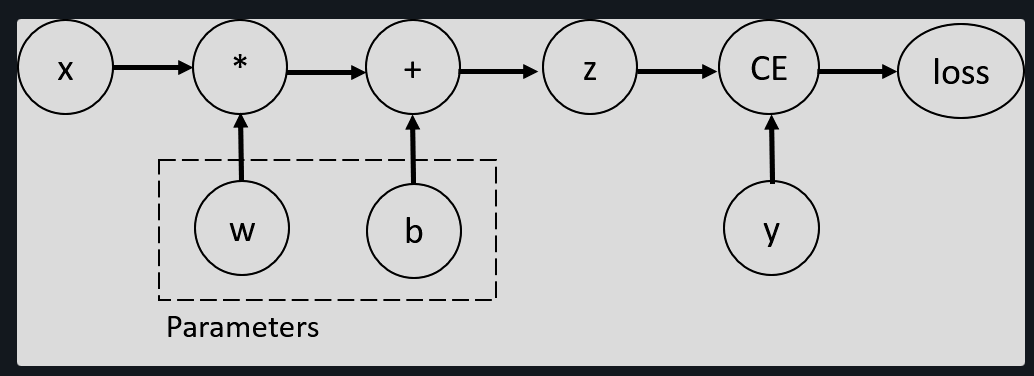

In [ ]:
# will demonstrate these concepts with a simple 1-layer network
#required_grad = True is how enable parameter tuning via loss function
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [45]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x79cebb7b0c70>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x79ceb8782e30>


In [ ]:
# the object you apply to tensor to compute computational graphs is of type function
#the function must be able to calculate the functon in the forward direction and also its derivative (backward direction)
# for a given tensor the backpropogation function is reference in the grad_fn property

In [46]:
#calling loss.backward computes the derivates of the loss function with respect to parameters where requires_grad = True
#fixes some value of x and y to derive these
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.1679, 0.1238, 0.2424],
        [0.1679, 0.1238, 0.2424],
        [0.1679, 0.1238, 0.2424],
        [0.1679, 0.1238, 0.2424],
        [0.1679, 0.1238, 0.2424]])
tensor([0.1679, 0.1238, 0.2424])


In [47]:
#when running a trained model do not need to calculate these gradients for back-prop (only going forwards) so wrap code in torch.no_grad()
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

#can also use detatch on a tensor
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

#this lets you freeze some parameters in your model
#speeds up computations when just passing forward with a trained model

True
False
False


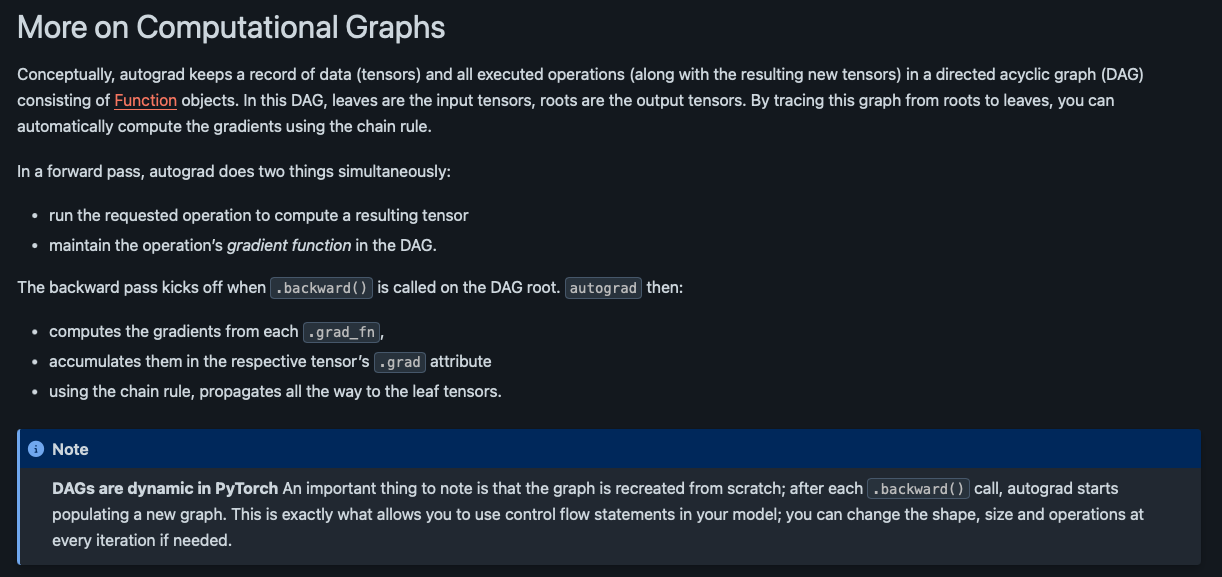

# Model Training


In [48]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

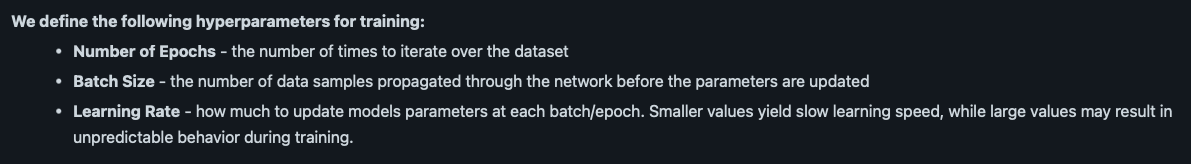

In [49]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

# Optimisation loop 

Each iteration of an optimisation loop is called and epoch

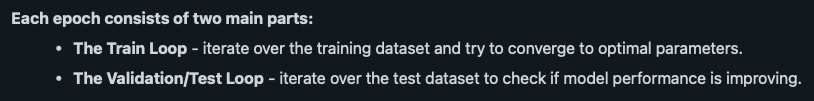

In [50]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()
#normalises the logits and computes the prediction error (loss function)

Optimisation is the process of adjusting parameters in each training loop to reduce the total error
- optimisation algorithms (like stochastic gradient descent) define how this is done
- optimisation objects store the logic for updating parameters

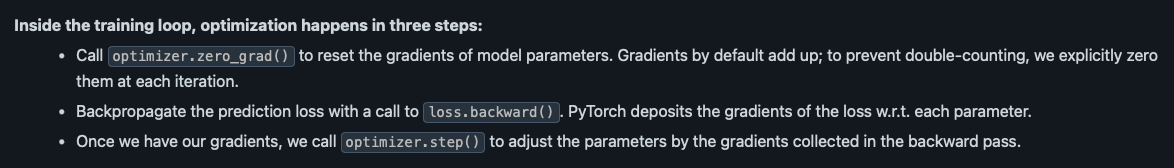

In [52]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.293549  [   64/60000]
loss: 2.279874  [ 6464/60000]
loss: 2.260039  [12864/60000]
loss: 2.258040  [19264/60000]
loss: 2.240583  [25664/60000]
loss: 2.200100  [32064/60000]
loss: 2.211804  [38464/60000]
loss: 2.172648  [44864/60000]
loss: 2.170103  [51264/60000]
loss: 2.138523  [57664/60000]
Test Error: 
 Accuracy: 50.9%, Avg loss: 2.128309 

Epoch 2
-------------------------------
loss: 2.136132  [   64/60000]
loss: 2.120715  [ 6464/60000]
loss: 2.063047  [12864/60000]
loss: 2.086682  [19264/60000]
loss: 2.022553  [25664/60000]
loss: 1.962161  [32064/60000]
loss: 1.994388  [38464/60000]
loss: 1.907501  [44864/60000]
loss: 1.912888  [51264/60000]
loss: 1.844070  [57664/60000]
Test Error: 
 Accuracy: 58.9%, Avg loss: 1.833089 

Epoch 3
-------------------------------
loss: 1.864601  [   64/60000]
loss: 1.826532  [ 6464/60000]
loss: 1.711817  [12864/60000]
loss: 1.764853  [19264/60000]
loss: 1.641143  [25664/60000]
loss: 1.598863  [32064/600

# Saving and loading models

Pytorch stores the weights of the model in an internal parameter dict

This can saved individually, then then the model loaded from the original model class and the inferred weights

In [55]:
import torch
import torchvision.models as models

In [57]:
model = models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), 'data/model_weights.pth')

In [58]:
#load model class so have structure to pass to weights
model = models.vgg16() # we do not specify ``weights``, i.e. create untrained model
#then load the weights but no need to load anything else as have model structure
model.load_state_dict(torch.load('data/model_weights.pth', weights_only=True))
#put in eval mode for normalisation and droput layer setting - ensures consistent inferences
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [60]:
# but when not using a pre-defined model might be better to save the weights with the model structure
torch.save(model, 'data/model.pth')

In [61]:
#but then need to load everything, not just the weights
model = torch.load('data/model.pth', weights_only=False)

In [66]:
X.shape

torch.Size([1, 28, 28])